# Lab 3
---
### Name: Mohammed Feras Sawab

### ID: 2240009066
---

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
img_path = r'images/cameraman.tif'
gray_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if gray_img is None:
    print(f'Error: Unable to load image at {img_path}')

In [3]:
def plot_images(images, titles):
    fig, ax = plt.subplots(1, len(images), figsize=(15, 5))

    for a, image, title in zip(ax, images, titles):
        a.imshow(image, cmap='gray', vmin=0, vmax=255)
        a.set_title(title)
        a.axis('off')

    plt.show()

### Task 1: Apply geometric transformations to an image

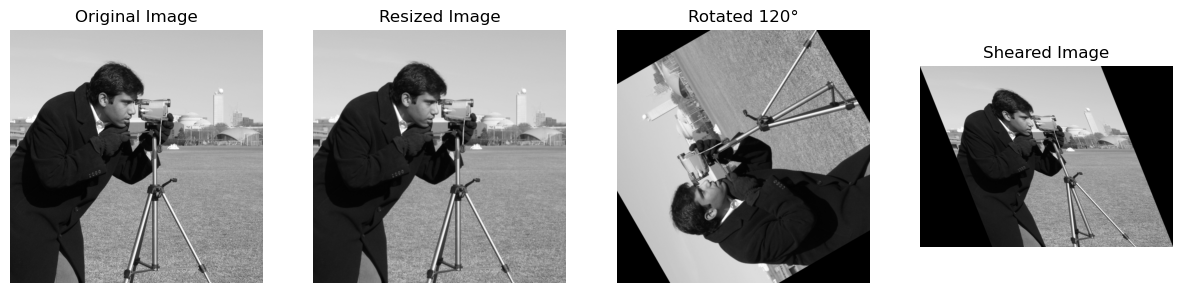

In [4]:
resized_img = cv2.resize(gray_img, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_LINEAR)

height, width = gray_img.shape
center = (width / 2, height / 2)
rotation_matrix = cv2.getRotationMatrix2D(center, 120, 1)
rotated_img = cv2.warpAffine(gray_img, rotation_matrix, (width, height))

shear_matrix = np.float32([[1, 0.4, 0], [0, 1, 0]])
sheared_img = cv2.warpAffine(gray_img, shear_matrix, (int(width * 1.4), height))

plot_images(
    [gray_img, resized_img, rotated_img, sheared_img],
    ['Original Image', 'Resized Image', 'Rotated 120°', 'Sheared Image']
)

### Task 2: Apply intensity transformations to an image

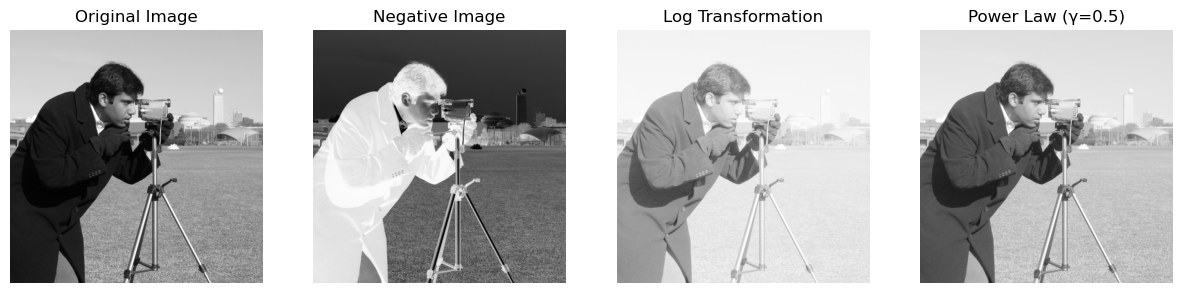

In [5]:
negative_img = 255 - gray_img

log_img = np.uint8(255 * np.log1p(gray_img) / np.log1p(gray_img.max()))

gamma = 0.5
power_img = np.uint8(255 * (gray_img / 255) ** gamma)

plot_images(
    [gray_img, negative_img, log_img, power_img],
    ['Original Image', 'Negative Image', 'Log Transformation', f'Power Law (γ={gamma})']
)